# False Data Injection (FDI) Attacks on Sensors

## Overview
False Data Injection (FDI) attacks occur when an adversary intentionally injects incorrect, manipulated, or spoofed sensor readings into a system to cause incorrect state estimation, control decisions, or analytics. FDI is a serious risk in cyber-physical systems (CPS), industrial control systems (ICS), IoT deployments, autonomous vehicles, robotics, and building/environmental monitoring.

## Threat Model
- Attacker goals: cause disruption, conceal events, bias analytics, trigger unsafe control actions, or degrade system performance.
- Attacker capabilities: may have network access, man-in-the-middle position, compromised sensor/node, or the ability to replay or synthesize sensor messages.
- Constraints: varying knowledge of system models, sensor fusion algorithms, timing, and authentication mechanisms.

## Common Attack Techniques
- Replay attacks: resend previously captured valid sensor readings to hide changes.
- Saturation/spoofing: send extreme values (outliers) to trigger alarms or saturate filters.
- Scaled/biased manipulation: add a constant offset or scale sensor values to bias estimates.
- Coordinated multi-sensor injection: manipulate multiple sensors consistently to evade simple plausibility checks and state estimators.
- Time-shift/tampering: alter timestamps or message ordering to break temporal fusion.

## Typical Impact
- Wrong control actions (e.g., unsafe actuator commands).
- Incorrect state estimation (e.g., wrong position, speed, temperature).
- False alarms or suppression of legitimate alarms.
- Long-term model drift and degraded ML models.
- Physical damage, safety hazards, downtime, or loss of trust.

## Detection Strategies
- Redundancy and cross-checks: use multiple independent sensors measuring the same quantity.
- Consistency checks: physics-based plausibility and invariant checking.
- Statistical and anomaly detection: monitor residuals from state estimators (e.g., Kalman filter residuals), use thresholding, clustering, or ML-based anomaly models.
- Time-series correlation: detect replay or timing anomalies by checking entropy, autocorrelation, and sequence uniqueness.
- Cryptographic integrity: message authentication codes (MACs) and signatures to prevent spoofing.

## Mitigation & Hardening
- Authentication and encryption: secure sensor-to-controller communications (TLS/DTLS, secure tokens).
- Secure boot and device attestation: ensure sensor firmware integrity and provenance.
- Rate limiting and freshness checks: reject stale or duplicated messages; use nonces or sequence numbers.
- Diversity and sensor fusion: combine heterogeneous sensors and incorporate physics-based models into fusion algorithms.
- Robust estimators: use outlier-resistant filters and attack-aware state estimation (e.g., robust Kalman filters, sparse attack detection).
- Network segmentation and least privilege: isolate critical sensors and limit access surfaces.
- Monitoring and logging: maintain end-to-end telemetry for post-incident forensics.

## Practical Recommendations
- Threat-model your deployment: identify high-impact sensors and likely attack vectors.
- Apply defense-in-depth: combine cryptography, redundancy, statistical detection, and operator policies.
- Test with adversarial scenarios: simulate replay, spoofing, and coordinated injections during development and drills.
- Keep firmware and keys managed: rotate keys, apply patches, and use secure provisioning.

## Example Scenario (concise)
A temperature sensor in an industrial process is spoofed by adding a constant offset. The control loop reduces cooling because readings appear higher, causing process overheating. Detection: residuals of a model-based estimator rise; mitigation: switch to redundant sensor and trigger fail-safe.

## Further Reading
- Research on attack-aware state estimation and resilient control.
- Industry guidance on ICS/SCADA security and IoT device hardening.


In [3]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

sys.path.insert(0, os.path.abspath(libs_dir))
sys.path.insert(0, os.path.abspath(dataset_dir))
sys.path.insert(0, os.path.abspath(models_dir))

print("Libs directory:", libs_dir)
print("Dataset directory:", dataset_dir)
print("Models directory:", models_dir)

from kelmanfilter import KalmanFilter1D, KalmanFilter2D
from websocketclient import WebSocketCollector, SensorStream

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../libs
Dataset directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../datasets
Models directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../models


In [22]:
collector = WebSocketCollector(ws_url, max_messages=100)
collector.collect()

WebSocket opened
WebSocket closed None


In [32]:
stream =SensorStream(collector.queue)
df = stream.get_as_dataframe()

temperature_values = df[['Temperature Sensor']].astype(float).values.flatten()
temperature_values = [_ for _ in temperature_values if not np.isnan(_)]
df.head()

,Sonar Sensor,Actual_Sonar Sensor,Velocity Sensor,Actual_Velocity Sensor,Temperature Sensor,Actual_Temperature Sensor,Temperature Sensor,Actual_Temperature Sensor
0,NaN,NaN,NaN,NaN,72.546057,62.1,NaN,NaN
1,NaN,NaN,NaN,NaN,52.915331,62.1,NaN,NaN
2,NaN,NaN,NaN,NaN,58.843207,62.1,NaN,NaN
3,NaN,NaN,NaN,NaN,59.801333,62.1,NaN,NaN
4,NaN,NaN,NaN,NaN,66.154254,62.1,NaN,NaN


In [33]:
kf = KalmanFilter1D(dt=0.1, X0=0.0, Q0=1e-10, R0=1e-3)
filtered_values = kf.filter(temperature_values)

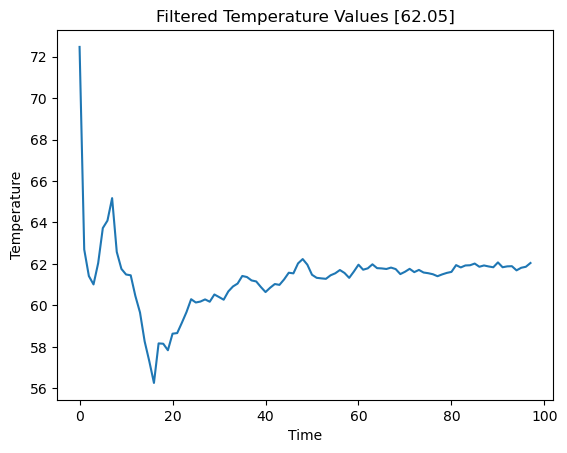

In [34]:
import matplotlib.pyplot as plt

plt.plot(filtered_values)
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(filtered_values[-1], 2)}]')
plt.show()


### Analyse the data

In [38]:
sniffer = WebSocketCollector(ws_url, max_messages=100)
sniffer.collect()

WebSocket opened
WebSocket closed None


In [40]:
stream =SensorStream(sniffer.queue)
df = stream.get_as_dataframe()

sniffed_temperature_values = df[['Temperature Sensor']].astype(float).values.flatten()
sniffed_temperature_values = [_ for _ in sniffed_temperature_values if not np.isnan(_)]

df.head()

,Sonar Sensor,Actual_Sonar Sensor,Velocity Sensor,Actual_Velocity Sensor,Temperature Sensor,Actual_Temperature Sensor,Temperature Sensor,Actual_Temperature Sensor
0,NaN,NaN,NaN,NaN,51.591402,62.1,131.906407,136.6
1,NaN,NaN,NaN,NaN,58.35545,62.1,140.864045,136.6
2,NaN,NaN,NaN,NaN,60.45893,62.1,136.442732,136.6
3,NaN,NaN,NaN,NaN,56.246443,62.1,130.284413,136.6
4,NaN,NaN,NaN,NaN,80.044198,62.1,131.096632,136.6


In [41]:
kf = KalmanFilter1D(dt=0.1, X0=0.0, Q0=1e-10, R0=1e-3)
sniffer_filtered_values = kf.filter(sniffed_temperature_values)

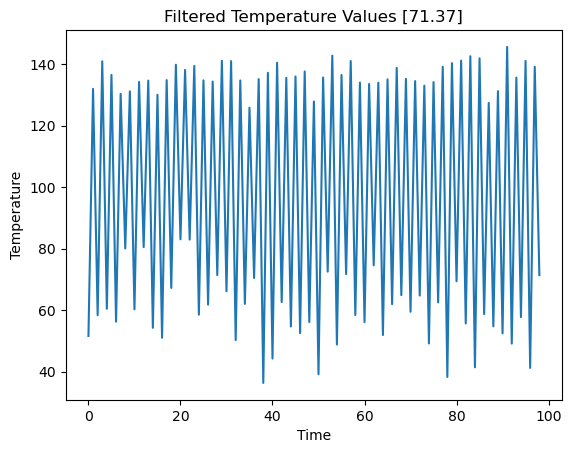

In [42]:
plt.plot(sniffed_temperature_values)
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(sniffed_temperature_values[-1], 2)}]')
plt.show()